# 📊 Market Risk Analysis Using GARCH Modeling and Value at Risk (VaR): A Case Study of Yum! Brands (KFC)

## 📖 Project Overview

This project aims to analyze and quantify market risk in equity returns using statistical and econometric techniques. Using historical stock price data from Yum! Brands (parent company of KFC), the analysis explores return behavior, volatility dynamics, and downside risk.

The project begins with an exploratory analysis of log returns and cumulative performance, followed by an investigation of volatility patterns using both historical and model-based approaches. A GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model is implemented to capture time-varying volatility and volatility clustering, which are key characteristics of financial markets.

To assess downside risk, Value at Risk (VaR) is computed using both historical methods and GARCH-based approaches. The project further evaluates the effectiveness of these methods by comparing their ability to capture market risk under different conditions.

Overall, this analysis demonstrates how combining statistical modeling with financial theory provides a more comprehensive framework for understanding and managing market risk.

---

## 🎯 Project Objectives

The main objectives of this project are:

- To analyze the behavior of stock returns using log returns and cumulative returns.
- To examine volatility patterns and identify periods of market stress and stability.
- To compute historical volatility and assess its limitations in capturing dynamic risk.
- To implement a GARCH model to capture time-varying volatility and volatility clustering.
- To compare different GARCH specifications and select the most appropriate model using AIC.
- To estimate Value at Risk (VaR) using both historical and GARCH-based approaches.
- To evaluate and compare the effectiveness of risk estimation methods.
- To highlight the importance of modeling assumptions, particularly in relation to tail risk and extreme events.
- To simulate returns using the GARCH model and assess its limitations in capturing extreme market behavior.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv ('KFC Stock Price Dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6025 non-null   object 
 1   Open       6025 non-null   float64
 2   High       6025 non-null   float64
 3   Low        6025 non-null   float64
 4   Close      6025 non-null   float64
 5   Adj Close  6025 non-null   float64
 6   Volume     6025 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 329.6+ KB
None


In [3]:
# convert the object column df['Date'] into datetime column and Drop Unwanted columns 
df['date']= pd.to_datetime(df['Date'])
df= df.drop(columns=['Date', 'High', 'Low', 'Close', 'Volume'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Open       6025 non-null   float64       
 1   Adj Close  6025 non-null   float64       
 2   date       6025 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2)
memory usage: 141.3 KB
None


In [4]:
# Calulate the Returns and Return_pct
df['log_return']= np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['log_return_pct']= df['log_return']*100
df= df.dropna()
print(df[['log_return', 'log_return_pct']]. head())

   log_return  log_return_pct
1     0.00000        0.000000
2     0.00000        0.000000
3     0.00000        0.000000
4    -0.00939       -0.938966
5     0.00000        0.000000


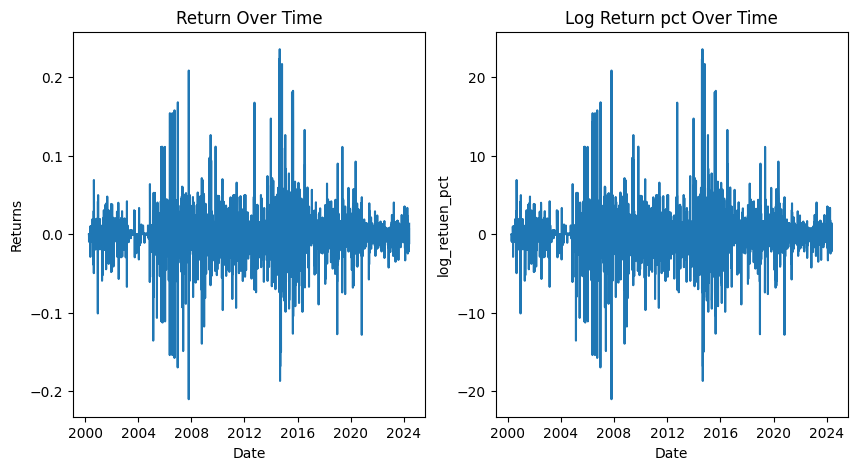

In [5]:
# Returns plot 
fig, axes= plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(df['date'], df['log_return'])
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Returns')
axes[0].set_title('Return Over Time')

axes[1].plot(df['date'], df['log_return_pct'])
axes[1].set_xlabel('Date')
axes[1].set_ylabel('log_retuen_pct')
axes[1].set_title('Log Return pct Over Time')

plt.tight_layout
plt.show()

## 📊 Cumulative Returns – Yum! Brands (KFC)

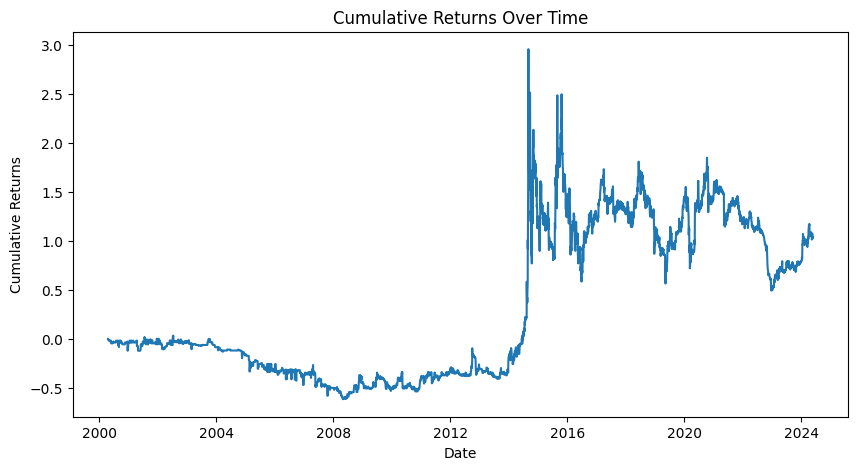

In [6]:
# Cumulative Return Plot 
df['cumulative_return'] = np.exp(df['log_return'].cumsum()) - 1
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['cumulative_return'])
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Cumulative Returns Over Time')
plt.show()

### 🔍 Overview
This section examines the cumulative performance of Yum! Brands (KFC) over time, providing insights into long-term value creation, market trends, and the impact of major economic events.

---

### 📊 Key Observations

- The cumulative returns exhibit a **prolonged decline in the early 2000s**, indicating a period of underperformance.
- A **stabilisation phase** follows, where returns flatten, suggesting a period of market adjustment and restructuring.
- A **sharp upward movement around 2014–2015** reflects a significant revaluation of the stock, likely driven by strategic changes and improved performance.
- Subsequent periods show **moderate growth with fluctuations**, indicating ongoing exposure to market conditions.
- A noticeable decline during **2020 highlights the impact of the COVID-19 shock**, followed by a recovery phase.

---

### 🧠 Interpretation

- The early downward trend suggests **persistent negative expectations**, likely driven by competitive pressures and structural challenges.
- The absence of high volatility during this decline indicates that the market response was **gradual and anticipated**, rather than driven by sudden shocks.
- The strong upward movement in later years reflects **renewed investor confidence and improved business fundamentals**.

---

### ⚡ Key Insight

> A sustained decline in cumulative returns combined with stable volatility suggests that negative expectations were already priced into the market, resulting in a steady downward adjustment rather than abrupt fluctuations.

---

### 📉 Risk Perspective

- Periods of sharp changes in cumulative returns are associated with **increased market uncertainty and volatility**.
- The recovery phases demonstrate the company’s **resilience and ability to adapt to changing economic conditions**.

---

### 🚀 Conclusion

The cumulative returns analysis highlights the cyclical nature of equity performance, driven by both internal strategic decisions and external macroeconomic factors. It reinforces the importance of considering long-term trends alongside short-term fluctuations when assessing investment performance.

## Daily Variance analysis 

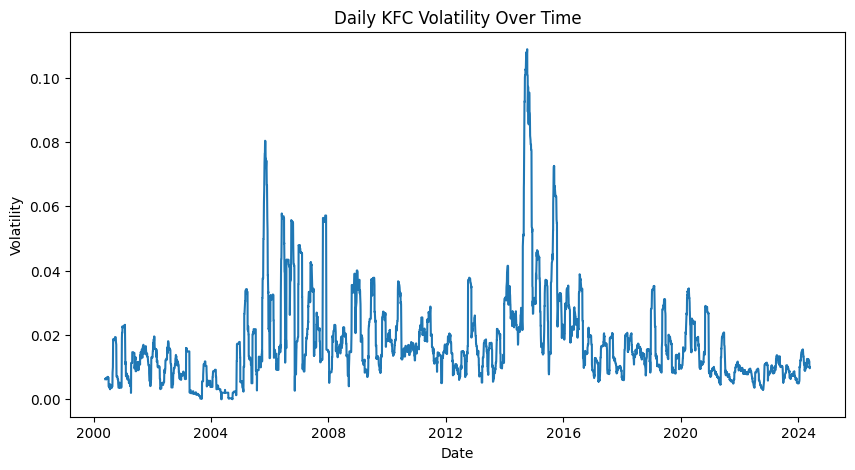

In [7]:
# computation of the variance 
df['volatility']= df['log_return'].rolling(window=30).std()
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['volatility'])
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Daily KFC Volatility Over Time')
plt.show()

### 🔍 Overview
This section examines the evolution of stock return volatility over time, highlighting periods of market stress, uncertainty, and stability, and linking these dynamics to observed changes in cumulative returns.

---

### 📉 Key Observations

- Volatility remains **relatively low and stable in the early 2000s**, despite a prolonged decline in cumulative returns.
- Significant **spikes in volatility occur during major market events**, particularly:
  - The **2008 Global Financial Crisis**
  - The **2014–2015 revaluation period**
  - The **COVID-19 shock in 2020**
- Following these spikes, volatility gradually declines, indicating a return to more stable market conditions.
- The overall pattern shows clear **volatility clustering**, where high-volatility periods are followed by further high volatility.

---

### 🧠 Interpretation

- The early period of declining cumulative returns combined with stable volatility suggests that market underperformance was **gradual and largely anticipated**, rather than driven by sudden shocks.
- Periods of sharp changes in cumulative returns (e.g., 2014–2015 and 2020) coincide with **increased volatility**, reflecting heightened uncertainty and rapid market repricing.
- The persistence of volatility following major spikes indicates that **market risk remains elevated even after initial shocks**, consistent with financial theory.

---

### ⚡ Key Insight

> Volatility does not necessarily increase during periods of steady decline, but spikes during periods of rapid market adjustment, indicating that volatility is driven more by uncertainty and unexpected shocks than by the direction of returns.

---

### 📉 Risk Perspective

- Low volatility during declining returns reflects **predictable underperformance**, where risks are already priced into the market.
- High volatility periods correspond to **market stress and uncertainty**, where risk levels increase significantly.
- The presence of volatility clustering suggests that **risk is time-dependent and persistent**, reinforcing the need for dynamic risk modeling approaches such as GARCH.

---

### 🚀 Conclusion

The volatility analysis complements the cumulative returns by showing that market risk is driven by uncertainty rather than performance direction. While returns capture long-term trends, volatility provides insight into the stability and predictability of those trends, making it a critical component of risk assessment.

## 📊 Relationship Between Competition, Returns, and Volatility

### 🔍 Key Question
Is there a correlation between increasing competition and stock volatility?

---

### 📉 Observed Pattern (2000 – 2004)
- **Cumulative returns:** Declining trend  
- **Volatility:** Relatively low and stable (≈ 1% – 2%)

---

### 🧠 Interpretation

At first glance, one might expect that increased competition would lead to higher volatility.  
However, the data suggests a different dynamic:

> The decline in returns during this period occurred alongside stable volatility, indicating that the market reaction was gradual rather than uncertain.

---

### ⚖️ Key Insight

- **Competition primarily affects returns (performance), not necessarily volatility (risk).**
- The steady decrease in returns suggests:
  - Loss of market share
  - Margin pressure due to competitive forces
- The stable volatility indicates:
  - These challenges were **anticipated by investors**
  - No major uncertainty or unexpected shocks occurred

---

### 💡 Analytical Conclusion

> A sustained decline in returns combined with low volatility suggests that negative expectations were already priced into the stock, resulting in a stable but downward adjustment rather than abrupt market reactions.

---

### 📊 Broader Implication

- **Returns measure direction** → how the company is performing  
- **Volatility measures uncertainty** → how unpredictable the market is  

This period reflects a scenario of:
> **“Predictable underperformance” rather than “uncertain risk”**

---

### 🚀 Business & Investment Perspective

For analysts and investors:
- Competitive pressure should be monitored as a **driver of long-term performance**
- However, it may not immediately translate into **higher risk (volatility)** unless:
  - The impact is sudden
  - The market is uncertain about future outcomes

## Historical Value at Risk 

In [8]:
# Computation of Historical VaR
confidence_level= 0.95
VaR_95= df['log_return_pct'].quantile(1-confidence_level)
print(f"VaR(95%) :{VaR_95:.4f}")

VaR(95%) :-2.7868


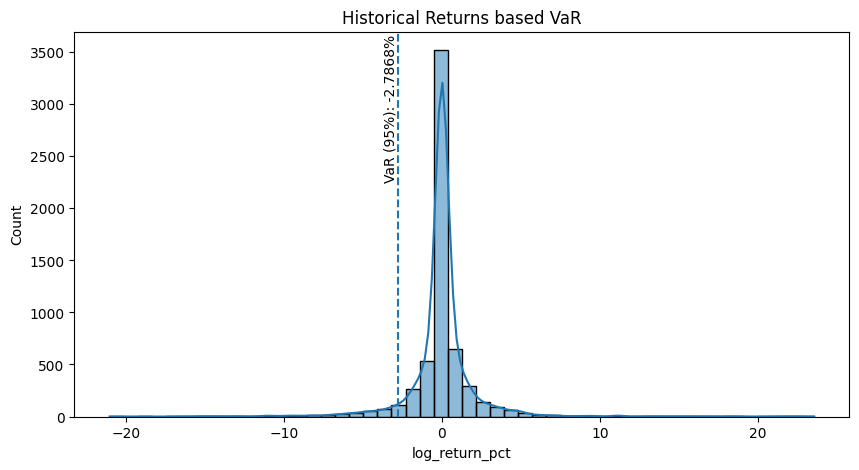

In [9]:
#Hisorical VaR plot 
plt.figure(figsize=(10,5))
sns.histplot(df['log_return_pct'], bins=50, kde=True)
plt.axvline(VaR_95, linestyle='--')
# ✅ Add label
plt.text(
    VaR_95,                     # x position
    plt.ylim()[1] * 0.8,        # y position (80% of height)
    f'VaR (95%): {VaR_95:.4f}%', # text
    rotation=90,
    verticalalignment='center',
    horizontalalignment='right'   # anchor text to the right (so it stays left of line)
)
plt.title('Historical Returns based VaR')
plt.show()

## 📊 Quantifying Market Risk Using Return Distribution and VaR

### 🔍 Overview
This chart illustrates the distribution of daily log returns for Yum! Brands (KFC), with a focus on downside risk measured using Value at Risk (VaR).

---

### 📈 Distribution of Returns
- The distribution is **centered around zero**, indicating that most daily returns are small.
- A high concentration of observations near the mean reflects **stable day-to-day performance**.
- However, the distribution exhibits **fat tails**, meaning extreme returns (both positive and negative) occur more frequently than expected under a normal distribution.

---

### ⚠️ Downside Risk – VaR (95%)
- The dashed vertical line represents the **95% Value at Risk (VaR)** at approximately **-2.79%**.
- This indicates:

> There is a 5% probability that daily returns will be worse than **-2.79%**.

---

### 🧠 Interpretation

- The left tail of the distribution captures **extreme negative returns**, which are critical for risk management.
- The presence of fat tails suggests:
  - Higher likelihood of **extreme losses**
  - Potential underestimation of risk if assuming normality

---

### 📊 Key Insights
- Most returns are relatively small, but **extreme losses do occur**.
- VaR provides a **clear threshold for potential downside risk**.
- The distribution highlights the importance of considering **tail risk**, not just average performance.

---

### 💡 Business & Investment Implications
- Investors should be aware that:
  - Losses beyond -2.79% can occur, especially during volatile periods
  - Risk management strategies (e.g., diversification, hedging) are essential
- VaR can be used to:
  - Set **risk limits**
  - Inform **position sizing decisions**
  - Monitor **market stress conditions**

---

### 🚀 Conclusion
This analysis demonstrates how combining return distribution with VaR provides a more comprehensive view of market risk, enabling better-informed investment and risk management decisions.

## GARCH MODEL 

In [10]:
from arch import arch_model

garch_model = arch_model(df['log_return_pct'], vol='Garch', p=1, q=2, mean='constant', dist='normal')
garch_fit = garch_model.fit(disp='off')

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:         log_return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -11881.1
Distribution:                  Normal   AIC:                           23772.1
Method:            Maximum Likelihood   BIC:                           23805.6
                                        No. Observations:                 6024
Date:                Thu, Apr 16 2026   Df Residuals:                     6023
Time:                        15:19:57   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu            -0.0296  1.836e-02     -1.612      0.107 

In [11]:
from arch import arch_model

# GARCH(1,1)
model_11 = arch_model(df['log_return_pct'], vol='Garch', p=1, q=1).fit(disp='off')

# GARCH(2,1)
model_21 = arch_model(df['log_return_pct'], vol='Garch', p=2, q=1).fit(disp='off')

# GARCH(1,2)
model_12 = arch_model(df['log_return_pct'], vol='Garch', p=1, q=2).fit(disp='off')

print("GARCH(1,1) AIC:", model_11.aic)
print("GARCH(2,1) AIC:", model_21.aic)
print("GARCH(1,2) AIC:", model_12.aic, "To use lowest AIC")

GARCH(1,1) AIC: 23802.008009389345
GARCH(2,1) AIC: 23804.005569667883
GARCH(1,2) AIC: 23772.120734252763 To use lowest AIC


## 📊 Conditional vs Historical Volatility Analysis

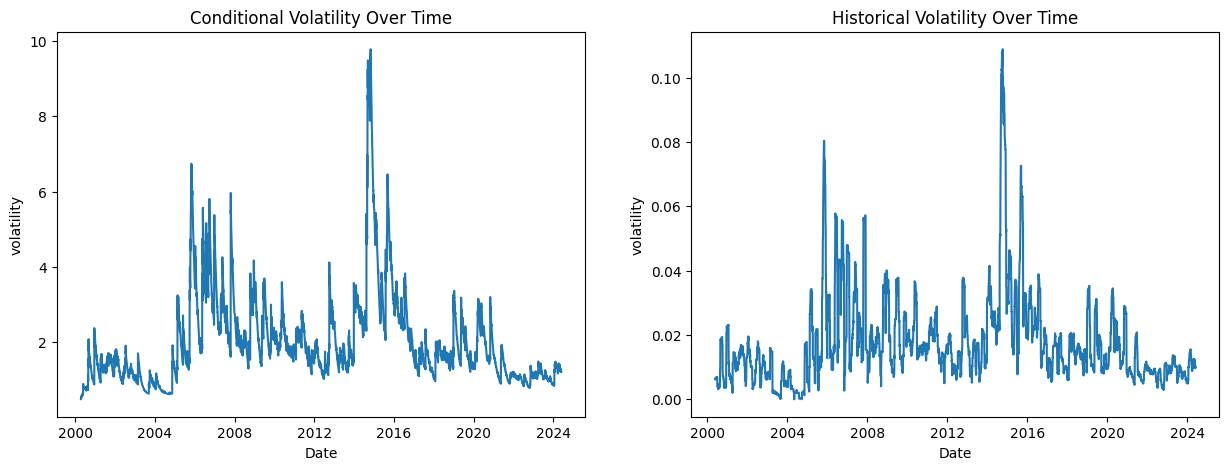

In [12]:
# plot the conditional Volatility and the Historical Volatility 
df['cond_volatility']= garch_fit.conditional_volatility

fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(df['date'], df['cond_volatility'])
axes[0].set_xlabel('Date')
axes[0].set_ylabel('volatility')
axes[0].set_title('Conditional Volatility Over Time')

axes[1].plot(df['date'], df['volatility'])
axes[1].set_title('Historical Volatility Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('volatility')
plt.show()

### 🔍 Overview
This analysis compares historical (rolling) volatility with GARCH-based conditional volatility to assess how different methods capture market risk.

---

### ⚡ Key Observations

- Both measures exhibit volatility clustering, with clear spikes during major market events such as the 2008 financial crisis and the COVID-19 shock in 2020.

- Historical volatility appears more noisy and reactive, as it is based solely on past observations within a fixed window.

- GARCH conditional volatility is smoother and more structured, reflecting its ability to model time-varying volatility dynamics.

---

### 🧠 Key Insight

The GARCH model captures volatility persistence more effectively, maintaining elevated risk levels following market shocks, whereas historical volatility tends to decline more rapidly.

---

### ⚠️ Risk Implication

- Historical volatility may underestimate risk in post-shock periods.
- GARCH volatility provides a more robust measure for risk management, as it incorporates both recent shocks and past volatility.

---

### 🚀 Conclusion

The comparison highlights the advantage of model-based approaches such as GARCH in capturing the dynamic and persistent nature of financial market volatility, making them more suitable for forecasting and risk assessment.

## GARCH based VaR

In [13]:
mu = garch_fit.params['mu']

# simulate returns
np.random.seed(42)
df['garch_simulated_return'] = mu + df['cond_volatility'] * np.random.normal(size=len(df))
print(df['garch_simulated_return'].head())

1    0.212878
2   -0.097067
3    0.290933
4    0.729970
5   -0.156404
Name: garch_simulated_return, dtype: float64


In [14]:
# Computation of Garch VaR
confidence_level= 0.95
GARCH_VaR_95= df['garch_simulated_return'].quantile(1-confidence_level)
print(f"GARCH_VaR(95%) :{GARCH_VaR_95:.4f}")

GARCH_VaR(95%) :-3.4869


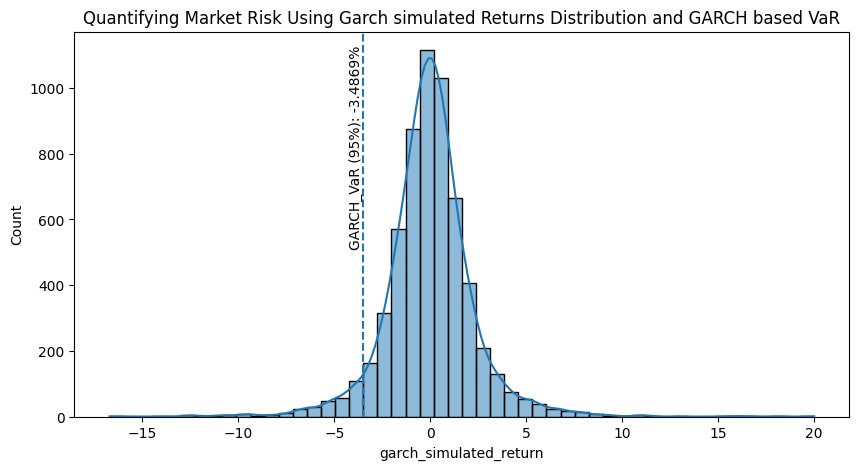

In [15]:
# Historical VaR plot 
plt.figure(figsize=(10,5))
sns.histplot(df['garch_simulated_return'], bins=50, kde=True)
plt.axvline(GARCH_VaR_95, linestyle='--')
# ✅ Add label
plt.text(
    GARCH_VaR_95,                     # x position
    plt.ylim()[1] * 0.7,        # y position (80% of height)
    f'GARCH_VaR (95%): {GARCH_VaR_95:.4f}%', # text
    rotation=90,
    verticalalignment='center',
    horizontalalignment='right'   # anchor text to the right (so it stays left of line)
)
plt.title('Quantifying Market Risk Using Garch simulated Returns Distribution and GARCH based VaR')
plt.show()

## 📊 Historical vs GARCH-based VaR Analysis

### 🔍 Overview
This analysis compares historical Value at Risk (VaR) with GARCH-based VaR to evaluate how incorporating time-varying volatility affects risk estimation.

---

### 📉 VaR Comparison

- Historical VaR (95%): ~ -2.78%  
- GARCH-based VaR (95%): ~ -3.49%  

---

### 🧠 Key Insight

The GARCH-based VaR is more conservative than the historical VaR, indicating a higher estimated downside risk.

---

### ⚡ Interpretation

- Historical VaR is static and based on past return distribution.
- GARCH-based VaR incorporates conditional volatility, making it responsive to changing market conditions.

As a result, GARCH VaR increases during periods of elevated volatility, leading to more conservative risk estimates.

---

### ⚠️ Important Consideration

Although the GARCH model assumes normally distributed returns, which may underestimate extreme tail events, its ability to capture volatility persistence leads to higher VaR estimates compared to historical methods.

---

### 🚀 Conclusion

The results demonstrate that incorporating time-varying volatility significantly improves risk estimation. However, further enhancements, such as using fat-tailed distributions, could provide a more accurate representation of extreme market risk.